# INIT

In [1]:
include("../alpcahFamily.jl")
include("../helperFunctions.jl")
using Plots
using Random
using Distributions
using LinearAlgebra
using MIRT
using HePPCAT
using ProgressMeter
using LaTeXStrings
using JLD

N = 500 # total points
D = 100 # ambient space
d = 10 # subspace rank
ν1 = 1 # 0.25 ORIGINAL
ν2 = 100
goodpts = 50 # 10 ORIGINAL
trials = 25;
ν = vcat(ν1*ones(goodpts), ν2*ones(N-goodpts));

# RPCA

In [23]:
function POGM_RPCA(Y, λr, r; niter::Int=100, flag::Bool=false)
    M,N = size(Y)
    A = hcat(Matrix(1.0I, M, N),Matrix(1.0I, M, N))
    B = vcat(A,A)
    Lf = opnorm(B)

    T = svd(Y)
    L = T.U[:,1:r]*Diagonal(sqrt.(T.S[1:r]))
    R = T.V[:,1:r]*Diagonal(sqrt.(T.S[1:r]))
    x0 = vcat(L*R',Y-L*R')
    
    grad = K -> repeat(-1*(Y-K[1:M,:]-K[(M+1):end,:]),2,1)
    #prox1 = (z,c) -> vcat(TSVT(z[1:M,:], c*λr, r), soft(z[M+1:end,:], c))
    prox1 = (z,c) -> vcat(SVST(z[1:M,:], c), prox_l21(z[M+1:end,:], c*λr))
    K, _ = pogm_restart(x0, x->0, grad, Lf ; g_prox=prox1, niter=niter, mom=:fpgm, restart=:gr)
    if flag == true
        return K[1:M,:], K[M+1:end,:] 
    end

    K = K[1:M,:] #,K[M+1:end,:]  Outlier matrix
    return svd(K).U[:,1:r]
end

prox_l21(X::AbstractArray, λ::Real; dims::Int=2) = prox_l21!(copy(X), λ; dims=dims)

function prox_l21!(X::AbstractArray, λ::Real; dims::Int=2, eps::Real=0.0)
    @assert 1 ≤ dims ≤ ndims(X)
    # iterate over groups as views (slices along `dims`)
    for g in eachslice(X; dims=dims)
        ng = norm(g)
        if ng ≤ λ + eps
            fill!(g, zero(eltype(X)))
        else
            g .*= (1 - λ/ng)
        end
    end
    return X
end

prox_l21! (generic function with 1 method)

# Data Generation

In [9]:
U1 = generateSubspace(D, d)
Y = generateData(U1, [ν1;ν2], [goodpts;N-goodpts]; coordinateWindow = 33, coordinateType = :uniform, seed=rand(1:100000));

In [10]:
YL = []
for i = 1:trials
    Y0 = generateData(U1, [ν1;ν2], [goodpts;N-goodpts]; coordinateWindow = 33, coordinateType = :uniform, seed=i);
    push!(YL,Y0)
end

# Small Trial

In [11]:
U_PCA = PCA(Y,d)
affinityError(U1, U_PCA)

0.3334069502981206

In [12]:
U_WPCA = weightedPCA(Y,ν,d);
affinityError(U1, U_WPCA)

0.10275386849133536

In [8]:
U_HEPPCAT = heppcatWrapper(Y, d; heppcatIter=100, varfloor= 1e-9)
affinityError(U1, U_HEPPCAT)

0.1646979954779382

In [9]:
U_ALPCAH_LR = LR_ALPCAH(Y,d; varfloor=1e-9, alpcahIter= 10)
affinityError(U1, U_ALPCAH_LR)

0.11543860122193922

In [45]:
λr = 0.0;
U_RPCA = POGM_RPCA(Y, λr, d; niter=100)
affinityError(U1, U_RPCA)

0.3334069502981177

In [38]:
L,S = POGM_RPCA(Y, λr, d; niter=100, flag=true)

([2.27034296266078 -7.693003250414901 … 2.899173889597505 -3.779113426458925; -4.627011692539368 -4.271333304437506 … -0.3221684115508846 -1.2437830553227611; … ; 0.04090756808686341 -7.06990512992544 … -1.6831194990455083 4.983199567011301; 1.4518348051389656 10.850117951604682 … 5.806644913260578 -10.046219559631812], [-1.1185366118906346 0.7791582486204204 … -11.749397622106 -11.35251524987391; -2.095233941840739 -0.5612855914453907 … 6.856699690543654 -10.363125010051121; … ; 0.564726502205867 -0.9689823422953118 … -5.118298757535507 11.69497320402366; 1.1352859606424968 0.5267463971389081 … 4.008557563928377 -1.0383977232515205])

In [41]:
using Plots
x = 1:500
p1 = heatmap(x, 1:size(S,1), S; color=:vik, clims=(-40,40),
             xlabel="", xformatter=_ -> "", ylabel="Ambient Dimension", cbar=false, title="RPCA (Classical) - Outlier Matrix S")

p2 = plot(x, ν; lw=2, legend=false,
          xlabel="Point Index", ylabel="Noise Variance")   # tweak until aligned

plot(p1, p2; layout=@layout([a; b]), link=:x, size=(800,600))
plt = plot(p1, p2; layout=@layout([a; b]), link=:x, size=(800,600))
savefig(plt, "rpca_L21.pdf")

"/home/javier/Desktop/ALPCAH/absolute_plots/rpca_L21.pdf"

# Full Trials (MUST BE SAME LENGTH!)

In [46]:
λr_alpcah = vcat(0.0:2.5:37.5)
λr_alpcah[1] = 0.1
# λr_alpcah_nuc = vcat(0.0:0.5:7.5)
# λr_alpcah_nuc[1] = 0.1;
λr_rpca = vcat(0.0:0.05:1.0)

21-element Vector{Float64}:
 0.0
 0.05
 0.1
 0.15
 0.2
 0.25
 0.3
 0.35
 0.4
 0.45
 0.5
 0.55
 0.6
 0.65
 0.7
 0.75
 0.8
 0.85
 0.9
 0.95
 1.0

In [49]:
wpcaMatrix = zeros(trials)
pcaMatrix = zeros(trials)
heppcatMatrix = zeros(trials)
alpcahlrMatrix = zeros(trials)
# alpcahMatrix = zeros(trials, length(λr_alpcah))
# alpcahNuclearMatrix = zeros(trials, length(λr_alpcah))
# rpcaMatrix = zeros(trials, length(λr_alpcah))
rpcaFacMatrix = zeros(trials, length(λr_rpca))

@showprogress for i=1:trials
    # PCA
    U_PCA = PCA(YL[i], d)
    pcaMatrix[i] = affinityError(U1, U_PCA) 
    
    # WPCA
    U_WPCA = weightedPCA(YL[i],ν,d);
    wpcaMatrix[i] = affinityError(U1, U_WPCA)
    
    # HEPPCAT
    U_HEPPCAT = heppcatWrapper(YL[i], d; heppcatIter=100, varfloor= 1e-9)
    heppcatMatrix[i] = affinityError(U1, U_HEPPCAT)

    # LR-ALPCAH
    U_ALPCAH_LR =  LR_ALPCAH(YL[i],d; varfloor=1e-9, alpcahIter= 10)
    alpcahlrMatrix[i] = affinityError(U1, U_ALPCAH_LR)
    
    Threads.@threads for j=1:length(λr_rpca)
        # # ALPCAH
        # U_ALPCAH = ALPCAH(YL[i], d, λr_alpcah[j]; μ=0.01, ρ=1.01, alpcahIter=100, varfloor=1e-9)
        # alpcahMatrix[i,j] = affinityError(U1, U_ALPCAH)

        # # ALPCAH NUCLEAR
        # U_ALPCAH_NUC = ALPCAH_NUCLEAR(YL[i], d, λr_alpcah_nuc[j]; μ=0.01, ρ=1.01, alpcahIter=100, varfloor=1e-9)
        # alpcahNuclearMatrix[i,j] = affinityError(U1, U_ALPCAH_NUC)

        # RPCA FACTORIZED
        U_RPCA_FAC =  POGM_RPCA(Y, λr_rpca[j], d; niter=100) #POGM_RPCA(YL[i], d; λ=λr_rpca[j], maxiter=10000)
        rpcaFacMatrix[i,j] = affinityError(U1, U_RPCA_FAC)

        # # RPCA
        # U_RPCA = POGM_RPCA(YL[i], λr_alpcah[j], d; niter=100)
        # rpcaMatrix[i,j] = affinityError(U1, U_RPCA)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:07:59


In [ ]:
#save("results_unknown.jld", "pca", pcaMatrix, "wpca", wpcaMatrix, "heppcat", heppcatMatrix, "lr-alpcah", alpcahlrMatrix, "alpcah", alpcahMatrix, "rpca", rpcaMatrix, "alpcah-nuclear", alpcahNuclearMatrix)

In [ ]:
# pcaMatrix = load("results_unknown.jld", "pca")
# wpcaMatrix = load("results_unknown.jld", "wpca")
# heppcatMatrix = load("results_unknown.jld", "heppcat")
# alpcahlrMatrix = load("results_unknown.jld", "lr-alpcah")
# alpcahMatrix = load("results_unknown.jld", "alpcah")
# rpcaMatrix = load("results_unknown.jld", "rpca")
# alpcahNuclearMatrix = load("results_unknown.jld", "alpcah-nuclear");

# Plotting

In [50]:
heppcat_mean = mean(heppcatMatrix)
pca_mean = mean(pcaMatrix)
wpca_mean = mean(wpcaMatrix);
alpcah_lr_mean = mean(alpcahlrMatrix);
# alpcah_mean = vec(mean(alpcahMatrix, dims=1));
# alpcah_nuclear_mean = vec(mean(alpcahNuclearMatrix, dims=1));
# rpca_mean = vec(mean(rpcaMatrix, dims=1));
rpcaFac_mean = vec(mean(rpcaFacMatrix, dims=1));

In [51]:
heppcat_std = std(heppcatMatrix)
pca_std = std(pcaMatrix)
wpca_std = std(wpcaMatrix);
alpcah_lr_std = std(alpcahlrMatrix);
# alpcah_std = vec(std(alpcahMatrix, dims=1));
# alpcah_nuclear_std = vec(std(alpcahNuclearMatrix, dims=1));
rpcaFac_std = vec(std(rpcaFacMatrix, dims=1));
#rpca_std = vec(std(rpcaMatrix, dims=1));

In [52]:
colors = theme_palette(:auto).colors

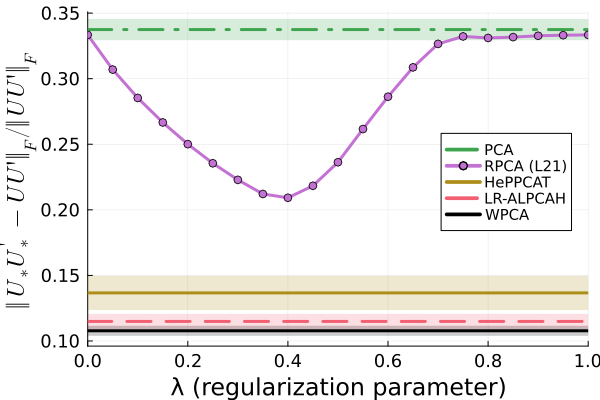

In [58]:
plot(xlabel="λ (regularization parameter)",ylabel=L"\Vert U_{*} U_{*}^{'}- UU' \Vert_F/ \Vert UU' \Vert_F");#alpcah_mean[2] = alpcah_mean[1];alpcah_std[2] = alpcah_std[1];
plot!(legend_position=:topright, legendfontpointsize=10,xtickfontsize=12,ytickfontsize=12,guidefontsize=16,titlefontsize=18, legend=:right)
hline!([pca_mean],ribbon=pca_std,c=colors[3], fillalpha = 0.2,linewidth=3, label="PCA", linestyle=:dashdot)
plot!(λr_rpca,rpcaFac_mean, ribbon=rpcaFac_std, fillalpha = 0.2, c=colors[4], linewidth=3, label="RPCA (L21)", markershape=:o)
hline!([heppcat_mean],ribbon=heppcat_std, c=colors[5], fillalpha = 0.2, linewidth=3, label="HePPCAT")
#plot!(λr_alpcah_nuc,alpcah_nuclear_mean, ribbon=alpcah_nuclear_std, fillalpha = 0.2, c=colors[2], linewidth=3, label="ALPCAH (d=0)", markershape=:uptriangle)
#plot!(λr_alpcah,alpcah_mean, ribbon=alpcah_std, fillalpha = 0.2, c=colors[1], linewidth=3, label="ALPCAH (d=10)", markershape=:x)
hline!([alpcah_lr_mean],ribbon=alpcah_lr_std, c=colors[end-2], fillalpha = 0.2, linewidth=3, label="LR-ALPCAH", linestyle=:dash)
hline!([wpca_mean],ribbon=wpca_std, c=:black, linewidth=3,fillalpha = 0.2, label="WPCA")
plot!(ylim=(wpca_mean-3*wpca_std, 0.351))
plot!(xlim=(0,1.0))
#lens!([2.5, 10], [0.1, 0.15], inset = (1, bbox(0.24, 0.31, 0.38, 0.38)), xaxis=true, yaxis=true)
#savefig("unknown_variance_rpca_l21.pdf")